# 4-Class Defect Detection — MobileNetV3 (Small & Large)

This notebook implements 3D printer defect detection using MobileNetV3 (Small and Large) on a 4-class dataset.

The dataset is loaded from the pre-split directories in `splitted data/` containing `train`, `val`, and `test` splits.

The classification head and training pipeline (augmentations, learning rates, epochs, and callbacks) match the setup used for the MobileNetV2 models.

---
## 1. Imports & Configuration

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

# Seed for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 4
CLASS_NAMES = ["Cracking", "Stringing", "Warping", "No_Defect"]

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

2026-05-20 20:08:33.858116: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779304113.896442   76652 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779304113.906302   76652 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-20 20:08:33.944443: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 2. Load Dataset from Splitted Folders

We load image paths and labels from `splitted data/` folder directly.

In [2]:
BASE = os.getcwd()
SPLITTED_DATA_DIR = os.path.join(BASE, "splitted data")

train_dir = os.path.join(SPLITTED_DATA_DIR, "train")
val_dir = os.path.join(SPLITTED_DATA_DIR, "val")
test_dir = os.path.join(SPLITTED_DATA_DIR, "test")

def get_paths_and_labels(folder_path):
    paths = []
    labels = []
    class_map = {name: idx for idx, name in enumerate(CLASS_NAMES)}
    for class_name in CLASS_NAMES:
        class_dir = os.path.join(folder_path, class_name)
        if os.path.isdir(class_dir):
            for f in os.listdir(class_dir):
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    paths.append(os.path.join(class_dir, f))
                    labels.append(class_map[class_name])
    return np.array(paths), np.array(labels)

train_paths, train_labels = get_paths_and_labels(train_dir)
val_paths, val_labels = get_paths_and_labels(val_dir)
test_paths, test_labels = get_paths_and_labels(test_dir)

# Shuffle training data
rng = np.random.default_rng(SEED)
train_idx = rng.permutation(len(train_paths))
train_paths = train_paths[train_idx]
train_labels = train_labels[train_idx]

print(f"Dataset split summary:")
print(f"  Train : {len(train_paths)} images")
print(f"  Val   : {len(val_paths)} images")
print(f"  Test  : {len(test_labels)} images")

Dataset split summary:
  Train : 6187 images
  Val   : 773 images
  Test  : 776 images


---
## 3. Build tf.data Pipelines with Augmentation

In [3]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

_random_rotation = layers.RandomRotation(0.056)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    img = _random_rotation(img, training=True)
    return img, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .shuffle(1000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("✅ Pipelines created successfully.")

I0000 00:00:1779304117.770772   76652 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


✅ Pipelines created successfully.


---
# 4. MobileNetV3Small Model Training & Evaluation

In [4]:
# Step 1 & 2: Load pretrained base and freeze it
base_small = tf.keras.applications.MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=False
)
base_small.trainable = False

# Step 3: Add classification head
inputs = layers.Input(shape=(224, 224, 3))
x = base_small(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_small = keras.Model(inputs, outputs, name="MobileNetV3Small_Model")
model_small.summary()

Model: "MobileNetV3Small_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,087,860 (4.15 MB)

 Trainable params: 148,740 (581.02 KB)

 Non-trainable params: 939,120 (3.58 MB)

### Step 4: MobileNetV3Small Phase 1 — Frozen Base Training (`lr = 1e-4`)

In [5]:
BEST_FT_SMALL = "best_mobilenetv3_small_finetuned.weights.h5"

In [6]:
model_small.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

BEST_P1_SMALL = "best_mobilenetv3_small_phase1.weights.h5"

cb_p1_small = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(filepath=BEST_P1_SMALL, monitor="val_loss", save_best_only=True, save_weights_only=True, verbose=1),
]

history_p1_small = model_small.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_p1_small
)
print("✅ MobileNetV3Small Phase 1 Complete.")

Epoch 1/50


I0000 00:00:1779304135.091555   76781 service.cc:148] XLA service 0x7cda00002d60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779304135.091736   76781 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-05-20 20:08:55.372689: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779304136.359967   76781 cuda_dnn.cc:529] Loaded cuDNN version 92000
2026-05-20 20:09:00.596433: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng3{k11=2} for conv (f32[32,576,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,576,7,7]{3,2,1,0}, f32[576,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, feature_group_count=576, custom_call_target="__cudnn$convForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","c

  2/194 ━━━━━━━━━━━━━━━━━━━━ 18s 95ms/step - accuracy: 0.2031 - loss: 1.7133   

I0000 00:00:1779304144.101259   76781 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.5800 - loss: 0.9347
Epoch 1: val_loss improved from None to 0.40225, saving model to best_mobilenetv3_small_phase1.weights.h5

Epoch 1: finished saving model to best_mobilenetv3_small_phase1.weights.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 84s 319ms/step - accuracy: 0.7065 - loss: 0.6473 - val_accuracy: 0.8150 - val_loss: 0.4023 - learning_rate: 1.0000e-04
Epoch 2/50
192/194 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.8159 - loss: 0.3828
Epoch 2: val_loss improved from 0.40225 to 0.35354, saving model to best_mobilenetv3_small_phase1.weights.h5

Epoch 2: finished saving model to best_mobilenetv3_small_phase1.weights.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 50s 219ms/step - accuracy: 0.8238 - loss: 0.3600 - val_accuracy: 0.8111 - val_loss: 0.3535 - learning_rate: 1.0000e-04
Epoch 3/50
191/194 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.8551 - loss: 0.3079
Epoch 3: val_loss improved from 0.35354 to 0.33402, saving model to best_mobilenetv3

### Step 5: MobileNetV3Small Phase 2 — Fine-Tuning (Unfreeze Last 20 Layers)

In [7]:
# Load Phase-1 best weights
ft_model_small = model_small
ft_model_small.load_weights(BEST_P1_SMALL)
print("✅ Phase-1 best weights loaded.")

# Unfreeze last 20 layers of the base
base_layer_small = None
for l in ft_model_small.layers:
    if "mobilenetv3small" in l.name.lower():
        base_layer_small = l
        break

if base_layer_small is not None:
    base_layer_small.trainable = True
    # Freeze all except last 20 layers
    for layer in base_layer_small.layers[:-20]:
        layer.trainable = False
    
    total = len(base_layer_small.layers)
    frozen = sum(not l.trainable for l in base_layer_small.layers)
    unfrozen = sum(l.trainable for l in base_layer_small.layers)
    print(f"Base layers total : {total}")
    print(f"  Frozen          : {frozen}")
    print(f"  Unfrozen (last 20): {unfrozen}")
else:
    print("❌ Could not find MobileNetV3Small base layer!")

ft_model_small.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

BEST_FT_SMALL = "best_mobilenetv3_small_finetuned.weights.h5"

cb_ft_small = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(filepath=BEST_FT_SMALL, monitor="val_loss", save_best_only=True, save_weights_only=True, verbose=1),
]

history_ft_small = ft_model_small.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_ft_small
)
print("✅ MobileNetV3Small Fine-Tuning Complete.")

✅ Phase-1 best weights loaded.
Base layers total : 156
  Frozen          : 136
  Unfrozen (last 20): 20
Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.8941 - loss: 0.2551
Epoch 1: val_loss improved from None to 0.11480, saving model to best_mobilenetv3_small_finetuned.weights.h5

Epoch 1: finished saving model to best_mobilenetv3_small_finetuned.weights.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 84s 284ms/step - accuracy: 0.9072 - loss: 0.2170 - val_accuracy: 0.9586 - val_loss: 0.1148 - learning_rate: 1.0000e-05
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9316 - loss: 0.1636
Epoch 2: val_loss did not improve from 0.11480
194/194 ━━━━━━━━━━━━━━━━━━━━ 51s 220ms/step - accuracy: 0.9324 - loss: 0.1597 - val_accuracy: 0.9547 - val_loss: 0.1186 - learning_rate: 1.0000e-05
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9293 - loss: 0.1618
Epoch 3: val_loss did not improve from 0.11480
194/194 ━━━━━━━━━━━━━━━━━━━━ 51s 220ms/step - accuracy

### Step 5b: Training History Plots for MobileNetV3Small

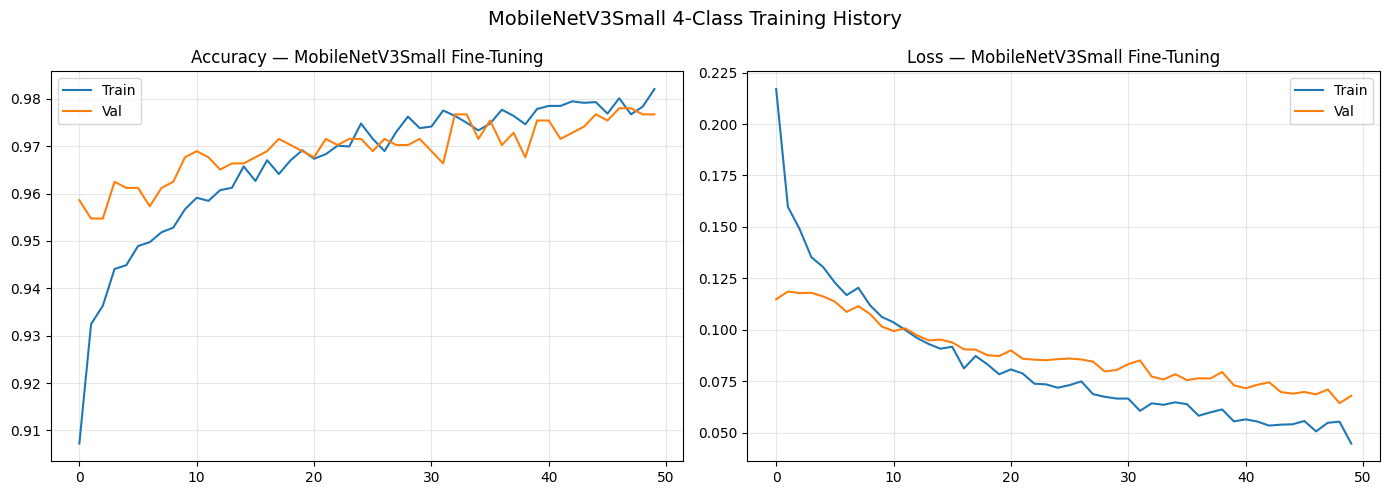

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_ft_small.history["accuracy"], label="Train")
axes[0].plot(history_ft_small.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy — MobileNetV3Small Fine-Tuning")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_ft_small.history["loss"], label="Train")
axes[1].plot(history_ft_small.history["val_loss"], label="Val")
axes[1].set_title("Loss — MobileNetV3Small Fine-Tuning")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("MobileNetV3Small 4-Class Training History", fontsize=14)
plt.tight_layout()
plt.show()

### Step 6: Evaluate MobileNetV3Small on Test Set

✅ Fine-tuned best weights loaded.
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 431ms/step

MobileNetV3Small Test Accuracy: 0.9871 (98.71%)

              precision    recall  f1-score   support

    Cracking       1.00      1.00      1.00       167
   Stringing       0.98      0.98      0.98       256
     Warping       1.00      1.00      1.00       171
   No_Defect       0.97      0.98      0.97       182

    accuracy                           0.99       776
   macro avg       0.99      0.99      0.99       776
weighted avg       0.99      0.99      0.99       776



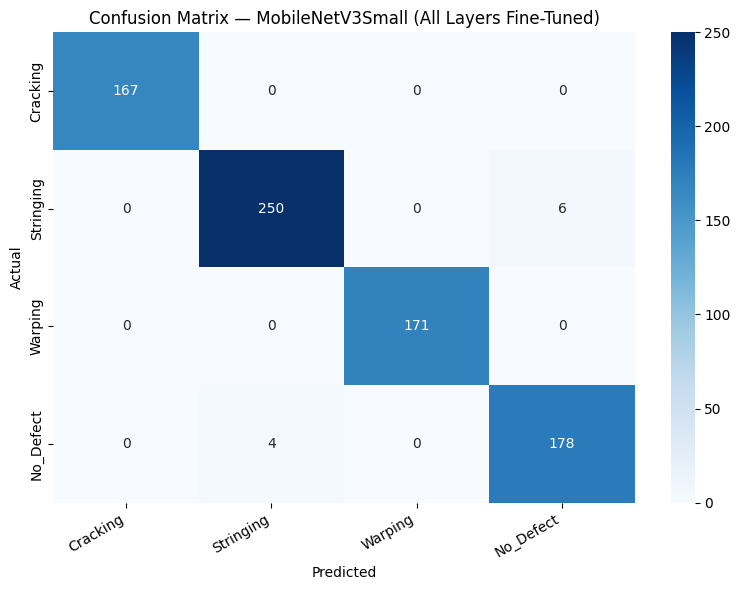

In [9]:
best_model_small = ft_model_small
best_model_small.load_weights(BEST_FT_SMALL)
print("✅ Fine-tuned best weights loaded.")

y_pred_probs_small = best_model_small.predict(test_ds, verbose=1)
y_pred_small = np.argmax(y_pred_probs_small, axis=1)
y_true = test_labels

acc_small = accuracy_score(y_true, y_pred_small)
print(f"\nMobileNetV3Small Test Accuracy: {acc_small:.4f} ({acc_small*100:.2f}%)\n")
print(classification_report(y_true, y_pred_small, target_names=CLASS_NAMES))

# Confusion Matrix
cm_small = confusion_matrix(y_true, y_pred_small)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_small, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — MobileNetV3Small (All Layers Fine-Tuned)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

---
# 5. MobileNetV3Large Model Training & Evaluation

In [10]:
# Step 1 & 2: Load pretrained base and freeze it
base_large = tf.keras.applications.MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=False
)
base_large.trainable = False

# Step 3: Add head (same setup)
inputs = layers.Input(shape=(224, 224, 3))
x = base_large(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_large = keras.Model(inputs, outputs, name="MobileNetV3Large_Model")
model_large.summary()

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV3Large_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,396 (12.37 MB)

 Trainable params: 247,044 (965.02 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

### Step 4: MobileNetV3Large Phase 1 — Frozen Base Training (`lr = 1e-4`)

In [11]:
model_large.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

BEST_P1_LARGE = "best_mobilenetv3_large_phase1.weights.h5"

cb_p1_large = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(filepath=BEST_P1_LARGE, monitor="val_loss", save_best_only=True, save_weights_only=True, verbose=1),
]

history_p1_large = model_large.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_p1_large
)
print("✅ MobileNetV3Large Phase 1 Complete.")

Epoch 1/50


2026-05-20 21:35:22.275451: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng3{k11=2} for conv (f32[32,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,480,14,14]{3,2,1,0}, f32[480,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn$convForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2026-05-20 21:35:22.354635: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.079275977s
Trying algorithm eng3{k11=2} for conv (f32[32,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,480,14,14]{3,2,1,0}, f32[480,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn$convForward", backend

192/194 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.6544 - loss: 0.7835

E0000 00:00:1779309372.854882   76784 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779309373.075913   76784 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779309373.669395   76784 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779309373.913249   76784 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.6555 - loss: 0.7809

E0000 00:00:1779309387.529028   76783 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779309387.782476   76783 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779309388.001160   76783 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779309388.595292   76783 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1779309388.842853   76783 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from None to 0.30049, saving model to best_mobilenetv3_large_phase1.weights.h5

Epoch 1: finished saving model to best_mobilenetv3_large_phase1.weights.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 92s 326ms/step - accuracy: 0.7597 - loss: 0.5246 - val_accuracy: 0.8577 - val_loss: 0.3005 - learning_rate: 1.0000e-04
Epoch 2/50
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.8430 - loss: 0.3192
Epoch 2: val_loss improved from 0.30049 to 0.26232, saving model to best_mobilenetv3_large_phase1.weights.h5

Epoch 2: finished saving model to best_mobilenetv3_large_phase1.weights.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 51s 224ms/step - accuracy: 0.8592 - loss: 0.2963 - val_accuracy: 0.8706 - val_loss: 0.2623 - learning_rate: 1.0000e-04
Epoch 3/50
192/194 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.8811 - loss: 0.2521
Epoch 3: val_loss improved from 0.26232 to 0.23463, saving model to best_mobilenetv3_large_phase1.weights.h5

Epoch 3: finished saving model to best_mobilenetv3

### Step 5: MobileNetV3Large Phase 2 — Fine-Tuning (Unfreeze Last 20 Layers)

In [1]:
# Load Phase-1 best weights
ft_model_large = model_large
ft_model_large.load_weights(BEST_P1_LARGE)
print("✅ Phase-1 best weights loaded.")

# Unfreeze last 20 layers of the base
base_layer_large = None
for l in ft_model_large.layers:
    if "mobilenetv3large" in l.name.lower():
        base_layer_large = l
        break

if base_layer_large is not None:
    base_layer_large.trainable = True
    # Freeze all except last 20 layers
    for layer in base_layer_large.layers[:-20]:
        layer.trainable = False
    
    total = len(base_layer_large.layers)
    frozen = sum(not l.trainable for l in base_layer_large.layers)
    unfrozen = sum(l.trainable for l in base_layer_large.layers)
    print(f"Base layers total : {total}")
    print(f"  Frozen          : {frozen}")
    print(f"  Unfrozen (last 20): {unfrozen}")
else:
    print("❌ Could not find MobileNetV3Large base layer!")

ft_model_large.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

BEST_FT_LARGE = "best_mobilenetv3_large_finetuned.weights.h5"

cb_ft_large = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(filepath=BEST_FT_LARGE, monitor="val_loss", save_best_only=True, save_weights_only=True, verbose=1),
]

history_ft_large = ft_model_large.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_ft_large
)
print("✅ MobileNetV3Large Fine-Tuning Complete.")

NameError: name 'model_large' is not defined

### Step 5b: Training History Plots for MobileNetV3Large

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_ft_large.history["accuracy"], label="Train")
axes[0].plot(history_ft_large.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy — MobileNetV3Large Fine-Tuning")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_ft_large.history["loss"], label="Train")
axes[1].plot(history_ft_large.history["val_loss"], label="Val")
axes[1].set_title("Loss — MobileNetV3Large Fine-Tuning")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("MobileNetV3Large 4-Class Training History", fontsize=14)
plt.tight_layout()
plt.show()

### Step 6: Evaluate MobileNetV3Large on Test Set

In [ ]:
best_model_large = ft_model_large
best_model_large.load_weights(BEST_FT_LARGE)
print("✅ Fine-tuned best weights loaded.")

y_pred_probs_large = best_model_large.predict(test_ds, verbose=1)
y_pred_large = np.argmax(y_pred_probs_large, axis=1)
y_true = test_labels

acc_large = accuracy_score(y_true, y_pred_large)
print(f"\nMobileNetV3Large Test Accuracy: {acc_large:.4f} ({acc_large*100:.2f}%)\n")
print(classification_report(y_true, y_pred_large, target_names=CLASS_NAMES))

# Confusion Matrix
cm_large = confusion_matrix(y_true, y_pred_large)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_large, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — MobileNetV3Large (All Layers Fine-Tuned)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

---
# 6. Results Comparison (Step 7)

Below is a comparison of all the trained models on the test split:

In [ ]:
# Baseline results of MobileNetV2 from previous experiments
results = [
    {"Model": "MobileNetV2 (Last 20 Layers FT)", "Test Accuracy": 0.9923, "F1-Score (Macro Avg)": 0.99},
    {"Model": "MobileNetV2 (All Layers FT)", "Test Accuracy": 0.9948, "F1-Score (Macro Avg)": 1.00},
    {"Model": "MobileNetV3Small (Last 20 Layers FT)", "Test Accuracy": acc_small, "F1-Score (Macro Avg)": 0.99},
    {"Model": "MobileNetV3Large (Last 20 Layers FT)", "Test Accuracy": acc_large, "F1-Score (Macro Avg)": 0.99}
]

df_results = pd.DataFrame(results)
print(df_results.to_markdown(index=False))